# 📥 Data & Library Import

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.tools
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn import metrics, svm

pd.set_option('display.max_columns', 100)

In [2]:
expectancy_data = pd.read_csv('../Life Expectancy Data.csv')


expectancy_data.columns = [c.strip().replace(' ', '_').replace('/', '_') for c in expectancy_data.columns]

expectancy_data.shape

(2864, 21)

In [3]:
def calculate_vif(X, thresh=5.0):
    """Drops the highest-VIF feature repeatedly until all remaining VIFs are under the threshold."""
    variables = list(range(X.shape[1]))
    dropped = True
    while dropped:
        dropped = False
        vif = [variance_inflation_factor(X.iloc[:, variables].values, ix)
               for ix in range(X.iloc[:, variables].shape[1])]
        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            print('dropping \'' + X.iloc[:, variables].columns[maxloc] +
                  '\' at index: ' + str(maxloc))
            del variables[maxloc]
            dropped = True
    print('Remaining variables:')
    print(X.columns[variables])
    return X.iloc[:, variables]

In [4]:
def stepwise_selection(X, y, threshold_in = 0.01, threshold_out = 0.05, verbose = True):
    # The function is checking for p-values (whether features are statistically significant) - lower is better
    included = [] # this is going to be the list of features we keep
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index = excluded, dtype = 'float64')
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        # we add the feature with the lowest (best) p-value under the threshold to our 'included' list
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval)) # specifying the verbose text


        # backward step: removing features if new features added to the list make them statistically insignificant
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        # if the p-value exceeds the upper threshold, the feature will be dropped from the 'included' list
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [5]:
def drop(df:pd.DataFrame, column:str, inplace:bool=False):
    if column in df.columns:
        return df.drop(column, axis=1, inplace=inplace)
    elif not inplace:
        return df

In [6]:
def standardize(arr):
    return (arr - np.mean(arr)) / np.std(arr)

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

---
# 🔎 Explore Data

In [7]:
expectancy_data.columns

Index(['Country', 'Region', 'Year', 'Infant_deaths', 'Under_five_deaths',
       'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
       'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
       'Population_mln', 'Thinness_ten_nineteen_years',
       'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed',
       'Economy_status_Developing', 'Life_expectancy'],
      dtype='str')

In [8]:
expectancy_data['Region'].unique()

<ArrowStringArray>
[                  'Middle East',                'European Union',
                          'Asia',                 'South America',
 'Central America and Caribbean',                'Rest of Europe',
                        'Africa',                       'Oceania',
                 'North America']
Length: 9, dtype: str

In [9]:
expectancy_data['Country'].unique()

<ArrowStringArray>
[           'Turkiye',              'Spain',              'India',
             'Guyana',             'Israel',         'Costa Rica',
 'Russian Federation',            'Hungary',             'Jordan',
            'Moldova',
 ...
           'Suriname',          'Mauritius',           'Barbados',
        'El Salvador',       'Burkina Faso',              'Qatar',
               'Fiji',          'Australia',    'North Macedonia',
            'Georgia']
Length: 179, dtype: str


### Data overview

In [10]:
# TODO: get an overview. head(), dtypes, describe(), shape.
display(expectancy_data.head())
print("\n--- Data Types ---")
print(expectancy_data.dtypes)
display(expectancy_data.describe())
print(f"\nShape: {expectancy_data.shape}")

# Look specifically at which columns are objects and which are numeric
object_cols = expectancy_data.select_dtypes(include=['object']).columns.tolist()
numeric_cols = expectancy_data.select_dtypes(exclude=['object']).columns.tolist()

print(f"\nObject columns: {object_cols}")
print(f"Numeric columns: {numeric_cols}")

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7



--- Data Types ---
Country                            str
Region                             str
Year                             int64
Infant_deaths                  float64
Under_five_deaths              float64
Adult_mortality                float64
Alcohol_consumption            float64
Hepatitis_B                      int64
Measles                          int64
BMI                            float64
Polio                            int64
Diphtheria                       int64
Incidents_HIV                  float64
GDP_per_capita                   int64
Population_mln                 float64
Thinness_ten_nineteen_years    float64
Thinness_five_nine_years       float64
Schooling                      float64
Economy_status_Developed         int64
Economy_status_Developing        int64
Life_expectancy                float64
dtype: object


,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,2007.500000,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.206704,0.793296,68.856075
std,4.610577,27.538117,44.569974,114.910281,3.981949,15.995511,18.659693,2.193905,15.080365,15.534225,2.381389,16934.788931,136.485867,4.438234,4.525217,3.171556,0.405012,0.405012,9.405608
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.750000,8.100000,9.675000,106.910250,1.200000,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1415.750000,2.097500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.600000,23.100000,163.841500,4.020000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4217.000000,7.850000,3.300000,3.400000,7.800000,0.000000,1.000000,71.400000
75%,2011.250000,47.350000,66.000000,246.791375,7.777500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12557.000000,23.687500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000



Shape: (2864, 21)

Object columns: ['Country', 'Region']
Numeric columns: ['Year', 'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita', 'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed', 'Economy_status_Developing', 'Life_expectancy']


### Correlation

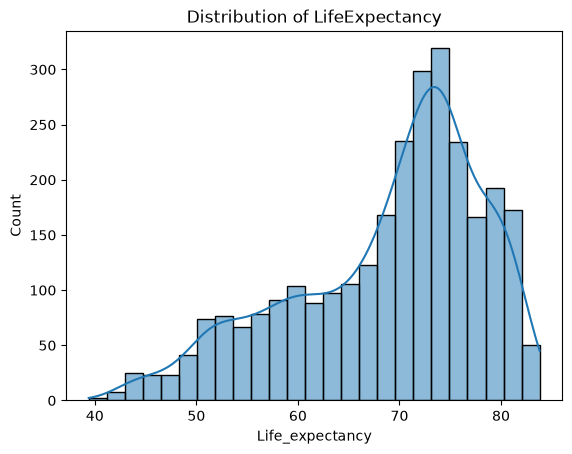


Strongest correlations with LifeExpectancy:
 Life_expectancy             1.000000
Schooling                   0.732484
Polio                       0.641217
Diphtheria                  0.627541
BMI                         0.598423
GDP_per_capita              0.583090
Economy_status_Developed    0.523791
Measles                     0.490019
Hepatitis_B                 0.417804
Alcohol_consumption         0.399159
Name: Life_expectancy, dtype: float64

Weakest correlations with LifeExpectancy:
 Economy_status_Developing   -0.523791
Incidents_HIV               -0.553027
Infant_deaths               -0.920032
Under_five_deaths           -0.920419
Adult_mortality             -0.945360
Name: Life_expectancy, dtype: float64


In [11]:
# TODO: look at the distribution of Life Expectancy and at the strongest correlations with it.
sns.histplot(expectancy_data['Life_expectancy'], kde=True)
plt.title('Distribution of LifeExpectancy')
plt.show()

# Calculate correlations for numeric columns only
numeric_df = expectancy_data.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Life_expectancy'].sort_values(ascending=False)
print("\nStrongest correlations with LifeExpectancy:\n", correlations.head(10))
print("\nWeakest correlations with LifeExpectancy:\n", correlations.tail(5))

In [12]:
# sns.pairplot(expectancy_data)
# plt.show()

### Check Nulls

In [13]:
# TODO: count the nulls in every column and show only the columns that have any.
nulls = expectancy_data.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))

Series([], dtype: int64)


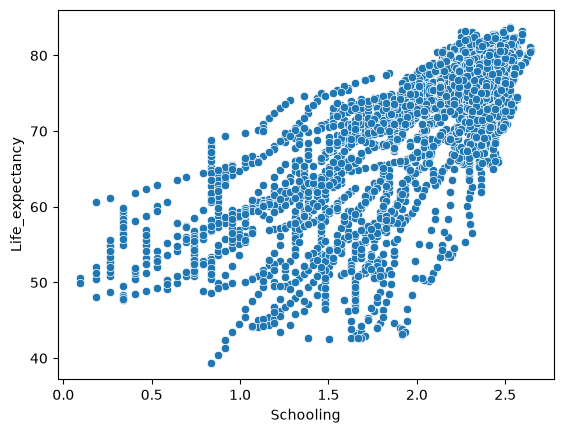

In [14]:
sns.scatterplot(
    x=np.log(expectancy_data['Schooling']), y=expectancy_data['Life_expectancy']
);

---
# 🧹 Data Preparation

### One Hot Encoding Regions

In [15]:
df = pd.get_dummies(expectancy_data, columns=['Region'], drop_first=True)

In [16]:
region_columns = [col for col in df.columns if col.startswith('Region_')]

### Split Data
... into least information and elaborate datasets.

In [17]:
# Model 1: Least Information (Privacy-Preserving)
least_information_columns = [
    "Life_expectancy",
    "Year",
    "Economy_status_Developed",
    "Economy_status_Developing",
    "Population_mln",
    "GDP_per_capita",
    "Schooling",
    
    # "Adult_mortality",
    # 'Under_five_deaths',
    # 'Incidents_HIV'
]

# Model 2: Elaborate (All Features)
# This includes the base features above, plus all sensitive medical/health records.
elaborate_columns = [
    "Life_expectancy",
    "Year",
    "Economy_status_Developed",
    "Economy_status_Developing",
    "Population_mln",
    "GDP_per_capita",
    "Schooling",
    "Infant_deaths",
    "Under_five_deaths",
    "Adult_mortality",
    "Alcohol_consumption",
    "Hepatitis_B",
    "Measles",
    "BMI",
    "Polio",
    "Diphtheria",
    "Incidents_HIV",
    "Thinness_ten_nineteen_years",
    "Thinness_five_nine_years"
]

In [18]:
least_information_columns = least_information_columns + region_columns
elaborate_columns = elaborate_columns + region_columns

In [19]:
df_least = df[least_information_columns]
df_elaborate = df[elaborate_columns]

In [20]:
df_least.head()

,Life_expectancy,Year,Economy_status_Developed,Economy_status_Developing,Population_mln,GDP_per_capita,Schooling,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America
0,76.5,2015,0,1,78.53,11006,7.8,False,False,False,True,False,False,False,False
1,82.8,2015,1,0,46.44,25742,9.7,False,False,True,False,False,False,False,False
2,65.4,2007,0,1,1183.21,1076,5.0,True,False,False,False,False,False,False,False
3,67.0,2006,0,1,0.75,4146,7.9,False,False,False,False,False,False,False,True
4,81.7,2012,1,0,7.91,33995,12.8,False,False,False,True,False,False,False,False


In [21]:
# df_least['GDP_per_capita_log'] = np.log(df_least['GDP_per_capita'])

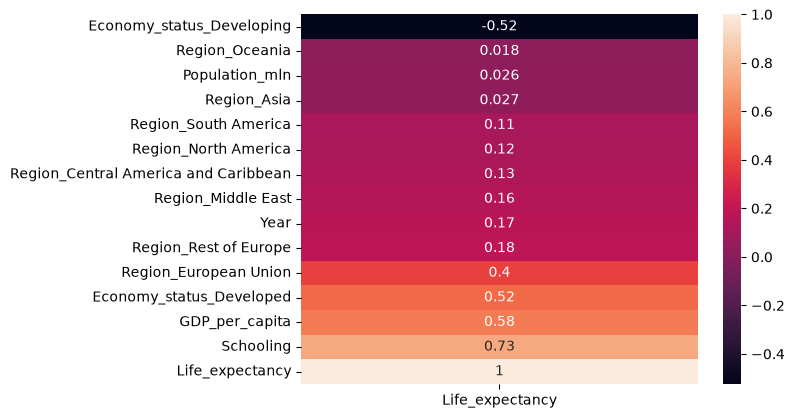

In [22]:
sns.heatmap(
    df_least.corr(numeric_only=True)[['Life_expectancy']].sort_values('Life_expectancy'),
    annot=True
)

plt.show()

In [23]:
# sns.pairplot(df_least[df_least.columns[::-1]])
# plt.show()

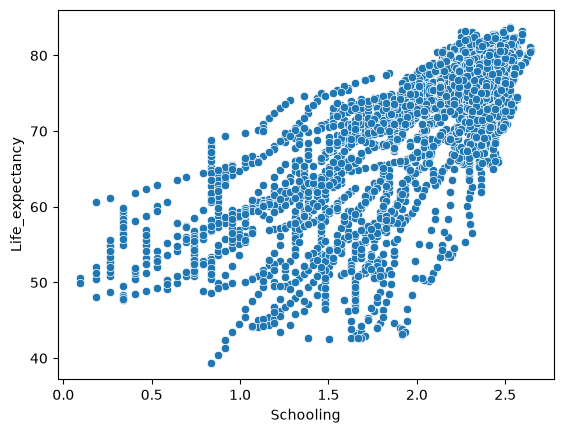

Correlation: 0.7257500571366432


In [24]:
taget_col = 'Schooling'

sns.scatterplot(
    x=np.log(df_least[taget_col]), y=df_least['Life_expectancy']
)
plt.show()

corr = np.corrcoef(np.log(df_least[taget_col]),df_least['Life_expectancy'])
print(f'Correlation: {corr[0,-1]}')

---
# 📑 Train-Test Split

In [25]:
def get_train_test(df, test_split:float=0.2, random_state=42, verbose:bool=False):
    # Fetch feature columns, and prepare features & labels
    feature_cols = list(df.columns)
    feature_cols.remove('Life_expectancy')

    X = df[feature_cols].astype(float)
    y = df['Life_expectancy']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state)

    if verbose:
        print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
        print(f' X_test: {X_test.shape}  |  y_test: {y_test.shape}')

    return X_train, X_test, y_train, y_test

---
# 🤖 Modelling

In [26]:
def fe_basic(df:pd.DataFrame):
    df['GDP_per_capita_log'] = np.log(df['GDP_per_capita'])

    drop(df, 'Economy_status_Developing', inplace=True)
    # drop(df, 'Economy_status_Developed', inplace=True)
    drop(df, 'GDP_per_capita', inplace=True)
    return df

## Full-Features

In [27]:
X_train, X_test, y_train, y_test = get_train_test(df_least)
X_train, X_test = fe_basic(X_train), fe_basic(X_test)

In [28]:
linreg = sm.OLS(y_train, X_train)
results = linreg.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:        Life_expectancy   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                          4.317e+04
Date:                Wed, 19 Aug 2026   Prob (F-statistic):                        0.00
Time:                        14:20:40   Log-Likelihood:                         -6653.2
No. Observations:                2291   AIC:                                  1.333e+04
Df Residuals:                    2278   BIC:                                  1.341e+04
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Year                                     0.0173      0.000     43.857      0.000       0.016       0.018
Economy_status_Developed                 1.4362      0.526      2.728      0.006       0.404       2.468
Population_mln                           0.0011      0.001      1.485      0.138      -0.000       0.002
Schooling                                0.2245      0.055      4.048      0.000       0.116       0.333
Region_Asia                              8.6191      0.333     25.919      0.000       7.967       9.271
Region_Central America and Caribbean     9.3178      0.382     24.371      0.000       8.568      10.068
Region_European Union                    8.1772      0.565     14.469      0.000       7.069       9.286
Region_Middle East                       8.5653      0.434     19.758      0.000       7.715       9.415
Region_North America                     8.2237      0.804     10.226      0.000       6.647       9.801
Region_Oceania                           7.0781      0.438     16.152      0.000       6.219       7.937
Region_Rest of Europe                    9.4010      0.451     20.860      0.000       8.517      10.285
Region_South America                     9.2884      0.430     21.615      0.000       8.446      10.131
GDP_per_capita_log                       3.0883      0.124     24.934      0.000       2.845       3.331
==============================================================================
Omnibus:                       96.158   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              263.193
Skew:                          -0.162   Prob(JB):                     7.05e-58
Kurtosis:                       4.629   Cond. No.                     2.08e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.08e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [29]:
y_train_pred = results.predict(X_train)
y_test_pred = results.predict(X_test)

full_train_rmse = sm.tools.eval_measures.rmse(y_train, y_train_pred)
full_test_rmse = sm.tools.eval_measures.rmse(y_test, y_test_pred)

print(f'Full-features train RMSE: {full_train_rmse.round(3)}')
print(f'Full-features test RMSE:  {full_test_rmse.round(3)}')

Full-features train RMSE: 4.415
Full-features test RMSE:  4.606


## VIF-Features

In [30]:
# Calculating VIF
vif_feature_cols = calculate_vif(X_train).columns

dropping 'GDP_per_capita_log' at index: 12
dropping 'Schooling' at index: 3
dropping 'Region_European Union' at index: 5
Remaining variables:
Index(['Year', 'Economy_status_Developed', 'Population_mln', 'Region_Asia',
       'Region_Central America and Caribbean', 'Region_Middle East',
       'Region_North America', 'Region_Oceania', 'Region_Rest of Europe',
       'Region_South America'],
      dtype='str')


In [31]:
X_train_vif, X_test_vif = X_train[vif_feature_cols], X_test[vif_feature_cols]

linreg = sm.OLS(y_train, X_train_vif)
results = linreg.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:        Life_expectancy   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                          3.430e+04
Date:                Wed, 19 Aug 2026   Prob (F-statistic):                        0.00
Time:                        14:20:40   Log-Likelihood:                         -7215.7
No. Observations:                2291   AIC:                                  1.445e+04
Df Residuals:                    2281   BIC:                                  1.451e+04
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Year                                     0.0293      0.000    281.360      0.000       0.029       0.029
Economy_status_Developed                17.1327      0.317     54.047      0.000      16.511      17.754
Population_mln                           0.0004      0.001      0.476      0.634      -0.001       0.002
Region_Asia                              9.9702      0.385     25.864      0.000       9.214      10.726
Region_Central America and Caribbean    13.7867      0.430     32.097      0.000      12.944      14.629
Region_Middle East                      14.0239      0.471     29.783      0.000      13.100      14.947
Region_North America                     7.7486      0.914      8.475      0.000       5.956       9.541
Region_Oceania                           7.4759      0.507     14.735      0.000       6.481       8.471
Region_Rest of Europe                   11.1316      0.440     25.327      0.000      10.270      11.993
Region_South America                    13.9466      0.492     28.335      0.000      12.981      14.912
==============================================================================
Omnibus:                       25.021   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.699
Skew:                           0.038   Prob(JB):                     1.45e-09
Kurtosis:                       3.649   Cond. No.                     1.56e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.56e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
y_train_pred = results.predict(X_train_vif)
y_test_pred = results.predict(X_test_vif)

vif_train_rmse = sm.tools.eval_measures.rmse(y_train, y_train_pred)
vif_test_rmse = sm.tools.eval_measures.rmse(y_test, y_test_pred)

print(f'VIF-features train RMSE: {vif_train_rmse.round(3)}')
print(f'VIF-features test RMSE: {vif_test_rmse.round(3)}')

VIF-features train RMSE: 5.644
VIF-features test RMSE: 5.738


## Stepwise-Features

In [33]:
def fe_stepwise(df:pd.DataFrame):
    df['GDP_per_capita_log'] = np.log(df['GDP_per_capita'])
    # drop(df, 'GDP_per_capita', inplace=True)
    df['Schooling_log'] = np.log(df['Schooling'])
    # drop(df, 'Schooling', inplace=True)

    df = sm.add_constant(df)
    return df

In [34]:
X_train, X_test, y_train, y_test = get_train_test(df_least, random_state=42)
X_train, X_test = fe_stepwise(X_train), fe_stepwise(X_test)

sw_feature_cols = stepwise_selection(X_train, y_train, verbose=False)
X_train, X_test = X_train[sw_feature_cols], X_test[sw_feature_cols]

print(X_train.columns)
display(X_train.head())

linreg = sm.OLS(y_train, X_train)
results = linreg.fit()
results.summary()

# results = RidgeCV()     # 4.203 – 4.506
# results = LassoCV()     # 4.251 – 4.536
# results.fit(X_train, y_train)
# print(results.score(X_train, y_train))

Index(['const', 'Schooling_log', 'GDP_per_capita_log', 'Region_Asia',
       'Region_Central America and Caribbean', 'Year', 'Region_Rest of Europe',
       'Region_South America', 'Region_European Union', 'Region_Middle East',
       'Region_Oceania', 'Region_North America', 'Economy_status_Developing',
       'Economy_status_Developed', 'Schooling', 'GDP_per_capita'],
      dtype='str')


,const,Schooling_log,GDP_per_capita_log,Region_Asia,Region_Central America and Caribbean,Year,Region_Rest of Europe,Region_South America,Region_European Union,Region_Middle East,Region_Oceania,Region_North America,Economy_status_Developing,Economy_status_Developed,Schooling,GDP_per_capita
2026,1.0,2.388763,8.214465,1.0,0.0,2014.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,10.9,3694.0
651,1.0,2.451005,9.551800,0.0,0.0,2004.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,11.6,14070.0
2225,1.0,2.302585,9.683838,0.0,0.0,2014.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,16056.0
2357,1.0,2.230014,8.182280,0.0,0.0,2010.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.3,3577.0
670,1.0,1.757858,8.101072,0.0,0.0,2003.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.8,3298.0


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_expectancy   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     663.7
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:20:41   Log-Likelihood:                -6540.2
No. Observations:                2291   AIC:                         1.311e+04
Df Residuals:                    2276   BIC:                         1.320e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -360.3320     26.066    -13.824      0.000    -411.447    -309.217
Schooling_log                            3.6683      0.735      4.991      0.000       2.227       5.110
GDP_per_capita_log                       3.4617      0.162     21.376      0.000       3.144       3.779
Region_Asia                              9.1296      0.306     29.854      0.000       8.530       9.729
Region_Central America and Caribbean     9.5158      0.370     25.729      0.000       8.791      10.241
Year                                     0.2855      0.019     14.641      0.000       0.247       0.324
Region_Rest of Europe                   10.4249      0.435     23.966      0.000       9.572      11.278
Region_South America                     9.3334      0.417     22.386      0.000       8.516      10.151
Region_European Union                    7.6405      0.566     13.506      0.000       6.531       8.750
Region_Middle East                       8.8007      0.414     21.253      0.000       7.989       9.613
Region_Oceania                           7.0587      0.421     16.785      0.000       6.234       7.883
Region_North America                     8.8012      0.765     11.511      0.000       7.302      10.301
Economy_status_Developing             -182.0963     13.055    -13.948      0.000    -207.698    -156.495
Economy_status_Developed              -178.2356     13.017    -13.693      0.000    -203.762    -152.710
Schooling                               -0.5891      0.132     -4.458      0.000      -0.848      -0.330
GDP_per_capita                       -4.562e-05   1.09e-05     -4.197      0.000   -6.69e-05   -2.43e-05
==============================================================================
Omnibus:                      117.357   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              340.855
Skew:                          -0.219   Prob(JB):                     9.64e-75
Kurtosis:                       4.838   Cond. No.                     1.01e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 9.77e-27. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [35]:
y_train_pred = results.predict(X_train)
y_test_pred = results.predict(X_test)

sw_train_rmse = sm.tools.eval_measures.rmse(y_train, y_train_pred)
sw_test_rmse = sm.tools.eval_measures.rmse(y_test, y_test_pred)

print(f'SW-features train RMSE: {sw_train_rmse.round(3)}')
print(f'SW-features test RMSE: {sw_test_rmse.round(3)}')

SW-features train RMSE: 4.203
SW-features test RMSE: 4.506


## Coarse-Features
Banding features where an exact value is replaced with a range/band.

In [ ]:
least_information_columns = [
    "Life_expectancy",
    
    "Year",
    # "Economy_status_Developed",
    # "Economy_status_Developing",
    "Population_mln",
    "GDP_per_capita",
    "Schooling",
    
    "Adult_mortality",
    'Under_five_deaths',
    'Incidents_HIV'
]

In [ ]:
bands = 10


[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

In [88]:
def get_bands(ds:pd.Series, bands:int=10):
    # edges = list(ds.quantile([0,.25,.5,.75,1]).values)
    # edges = list(ds.quantile([0,.2,.4,.6,.8,1]).values)
    edges = list(ds.quantile([x/bands for x in range(bands+1)]).values)
    edges[0], edges[-1] = -np.inf, np.inf
    return edges

def coarsen_col(ds:pd.Series):
    edges = get_bands(ds)
    ds = pd.cut(ds, edges, labels=False)
    

def fe_coarse(df):
    # Transform GDP/capita to log scale
    df['GDP_per_capita_log'] = np.log(df['GDP_per_capita'])
    drop(df, 'GDP_per_capita', inplace=True)
    # df['Schooling_log'] = np.log(df['Schooling'])
    # drop(df, 'Schooling', inplace=True)

    # Coarsen columns to hide sensitive data
    dxt = get_train_test(df_least)[0] # dummy_X_train
    columns = ['Adult_mortality', 'Under_five_deaths', 'Incidents_HIV']

    for col in columns:
        edges = get_bands(dxt[col])
        print(f'{col}: {edges}')
        df[col+''] = pd.cut(df[col], edges, labels=False)

    df = sm.add_constant(df)
    return df


In [89]:
df_least = df[least_information_columns + region_columns]

X_train, X_test, y_train, y_test = get_train_test(df_least)
X_train, X_test = fe_coarse(X_train), fe_coarse(X_test)

# sw_feature_cols = variance_inflation_factor(X_train, y_train, verbose=True)
# X_train, X_test = X_train[sw_feature_cols], X_test[sw_feature_cols]

display(X_train.head())

linreg = sm.OLS(y_train, X_train)
results = linreg.fit()
results.summary()

# results = RidgeCV()
# results.fit(X_train, y_train)
# print(results.score(X_train, y_train))

Adult_mortality: [-inf, np.float64(73.0145), np.float64(94.6415), np.float64(120.157), np.float64(141.9155), np.float64(164.1015), np.float64(190.0275), np.float64(224.272), np.float64(272.4865), np.float64(347.234), inf]
Under_five_deaths: [-inf, np.float64(4.7), np.float64(7.5), np.float64(11.7), np.float64(17.2), np.float64(23.3), np.float64(33.1), np.float64(55.6), np.float64(78.8), np.float64(112.5), inf]
Incidents_HIV: [-inf, np.float64(0.03), np.float64(0.07), np.float64(0.08), np.float64(0.13), np.float64(0.16), np.float64(0.19), np.float64(0.4), np.float64(0.76), np.float64(2.41), inf]
Adult_mortality: [-inf, np.float64(73.0145), np.float64(94.6415), np.float64(120.157), np.float64(141.9155), np.float64(164.1015), np.float64(190.0275), np.float64(224.272), np.float64(272.4865), np.float64(347.234), inf]
Under_five_deaths: [-inf, np.float64(4.7), np.float64(7.5), np.float64(11.7), np.float64(17.2), np.float64(23.3), np.float64(33.1), np.float64(55.6), np.float64(78.8), np.float

,const,Year,Population_mln,Schooling,Adult_mortality,Under_five_deaths,Incidents_HIV,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America,GDP_per_capita_log
2026,1.0,2014.0,20.78,10.9,2,2,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.214465
651,1.0,2004.0,10.20,11.6,2,0,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.551800
2225,1.0,2014.0,30.04,10.0,4,4,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.683838
2357,1.0,2010.0,2.91,9.3,1,3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.182280
670,1.0,2003.0,1.88,5.8,9,7,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.101072


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_expectancy   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     2299.
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:54:02   Log-Likelihood:                -5215.1
No. Observations:                2291   AIC:                         1.046e+04
Df Residuals:                    2275   BIC:                         1.055e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -116.1819     22.732     -5.111      0.000    -160.760     -71.603
Year                                     0.0988      0.011      8.795      0.000       0.077       0.121
Population_mln                        4.606e-05      0.000      0.120      0.905      -0.001       0.001
Schooling                               -0.0230      0.032     -0.711      0.477      -0.087       0.040
Adult_mortality                         -1.4138      0.044    -32.467      0.000      -1.499      -1.328
Under_five_deaths                       -1.4647      0.060    -24.273      0.000      -1.583      -1.346
Incidents_HIV                           -0.3399      0.028    -12.355      0.000      -0.394      -0.286
Region_Asia                              2.7983      0.203     13.763      0.000       2.400       3.197
Region_Central America and Caribbean     5.2090      0.212     24.616      0.000       4.794       5.624
Region_European Union                    0.8784      0.283      3.103      0.002       0.323       1.434
Region_Middle East                       1.1110      0.259      4.287      0.000       0.603       1.619
Region_North America                     3.5285      0.428      8.239      0.000       2.689       4.368
Region_Oceania                           1.9186      0.249      7.692      0.000       1.429       2.408
Region_Rest of Europe                    1.4095      0.289      4.881      0.000       0.843       1.976
Region_South America                     5.0028      0.235     21.305      0.000       4.542       5.463
GDP_per_capita_log                      -0.0592      0.082     -0.722      0.470      -0.220       0.102
==============================================================================
Omnibus:                      362.995   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              933.910
Skew:                          -0.863   Prob(JB):                    1.60e-203
Kurtosis:                       5.608   Cond. No.                     9.24e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.24e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [90]:
y_train_pred = results.predict(X_train)
y_test_pred = results.predict(X_test)

co_train_rmse = sm.tools.eval_measures.rmse(y_train, y_train_pred)
co_test_rmse = sm.tools.eval_measures.rmse(y_test, y_test_pred)

print(f'Coarse-features train RMSE: {co_train_rmse.round(3)}')
print(f'Coarse-features test RMSE: {co_test_rmse.round(3)}')

Coarse-features train RMSE: 2.357
Coarse-features test RMSE: 2.378


## Normalize-Features

In [293]:
least_information_columns = [
    "Life_expectancy",
    "Year",
    # "Economy_status_Developed",
    # "Economy_status_Developing",
    "Population_mln",
    "GDP_per_capita",
    "Schooling",
    
    "Adult_mortality",
    'Under_five_deaths',
    'Incidents_HIV'
]

In [294]:
def fe_normalize(df):
    df = fe_coarse(df)

    df['Population_mln'] = standardize(df['Population_mln'])
    df['Schooling'] = standardize(df['Schooling'])

    return df

In [295]:
df_least = df[least_information_columns + region_columns]

X_train, X_test, y_train, y_test = get_train_test(df_least)
X_train, X_test = fe_normalize(X_train), fe_normalize(X_test)

print(X_train.columns)
display(X_train.head())

linreg = sm.OLS(y_train, X_train)
results = linreg.fit()
results.summary()

Index(['const', 'Year', 'Population_mln', 'Schooling', 'Adult_mortality',
       'Under_five_deaths', 'Incidents_HIV', 'Region_Asia',
       'Region_Central America and Caribbean', 'Region_European Union',
       'Region_Middle East', 'Region_North America', 'Region_Oceania',
       'Region_Rest of Europe', 'Region_South America', 'GDP_per_capita_log'],
      dtype='str')


,const,Year,Population_mln,Schooling,Adult_mortality,Under_five_deaths,Incidents_HIV,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America,GDP_per_capita_log
2026,1.0,2014.0,-0.117407,1.016169,1,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.214465
651,1.0,2004.0,-0.194487,1.235473,1,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.551800
2225,1.0,2014.0,-0.049945,0.734206,1,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.683838
2357,1.0,2010.0,-0.247597,0.514901,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.182280
670,1.0,2003.0,-0.255101,-0.581621,3,3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.101072


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_expectancy   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     1539.
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:55:00   Log-Likelihood:                -5640.2
No. Observations:                2291   AIC:                         1.131e+04
Df Residuals:                    2275   BIC:                         1.140e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -235.8299     27.061     -8.715      0.000    -288.898    -182.762
Year                                     0.1526      0.013     11.403      0.000       0.126       0.179
Population_mln                          -0.0174      0.064     -0.273      0.785      -0.142       0.107
Schooling                                0.0018      0.122      0.015      0.988      -0.237       0.241
Adult_mortality                         -3.3047      0.113    -29.251      0.000      -3.526      -3.083
Under_five_deaths                       -2.5081      0.144    -17.463      0.000      -2.790      -2.226
Incidents_HIV                           -1.0617      0.080    -13.319      0.000      -1.218      -0.905
Region_Asia                              3.7735      0.240     15.752      0.000       3.304       4.243
Region_Central America and Caribbean     5.9976      0.254     23.639      0.000       5.500       6.495
Region_European Union                    2.1461      0.331      6.480      0.000       1.497       2.796
Region_Middle East                       1.9082      0.311      6.140      0.000       1.299       2.518
Region_North America                     4.3278      0.517      8.376      0.000       3.315       5.341
Region_Oceania                           2.8748      0.296      9.719      0.000       2.295       3.455
Region_Rest of Europe                    2.9602      0.337      8.777      0.000       2.299       3.622
Region_South America                     5.4870      0.283     19.396      0.000       4.932       6.042
GDP_per_capita_log                       0.7104      0.092      7.701      0.000       0.529       0.891
==============================================================================
Omnibus:                      278.681   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              656.641
Skew:                          -0.705   Prob(JB):                    2.58e-143
Kurtosis:                       5.212   Cond. No.                     9.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [296]:
y_train_pred = results.predict(X_train)
y_test_pred = results.predict(X_test)

no_train_rmse = sm.tools.eval_measures.rmse(y_train, y_train_pred)
no_test_rmse = sm.tools.eval_measures.rmse(y_test, y_test_pred)

print(f'Normalize-features train RMSE: {no_train_rmse.round(3)}')
print(f'Normalize-features test RMSE: {no_test_rmse.round(3)}')

Normalize-features train RMSE: 2.838
Normalize-features test RMSE: 2.896


# 🏁 RMSE Rankings

In [297]:
print(f"Full Features:\n\t{full_train_rmse.round(3)} – {full_test_rmse.round(3)}", end='\n\n')
print(f"VIF Features:\n\t{vif_train_rmse.round(3)} – {vif_test_rmse.round(3)}", end='\n\n')
print(f"Stepwise Features:\n\t{sw_train_rmse.round(3)} – {sw_test_rmse.round(3)}", end='\n\n')
print(f"Coarse Features:\n\t{co_train_rmse.round(3)} – {co_test_rmse.round(3)}", end='\n\n')
print(f"Normalized Features:\n\t{no_train_rmse.round(3)} – {no_test_rmse.round(3)}", end='\n\n')

Full Features:
	4.415 – 4.606

VIF Features:
	5.644 – 5.738

Stepwise Features:
	4.243 – 4.534

Coarse Features:
	2.838 – 2.896

Normalized Features:
	2.838 – 2.896



---
# `models.py` Testing

In [298]:
import models

In [299]:
mode = 'coarse'

fit, apply = models.MODELS[mode]['fit'], models.MODELS[mode]['apply']
features = models.MODELS[mode]['features']

X = df.drop(columns=["Life_expectancy"])     # features
y = df["Life_expectancy"]                    # the answers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

state = fit(X_train) # <- YOUR fit, called once

train_fe = sm.add_constant(apply(X_train, state)[features])   # <- YOUR apply

test_fe  = sm.add_constant(apply(X_test,  state)[features])   # <- YOUR apply

model = sm.OLS(y_train, train_fe).fit() # <<<<<< MODEL IS TRAINED HERE
test_rmse = sm.tools.eval_measures.rmse(y_test, model.predict(test_fe))

test_rmse

np.float64(2.8962076382970228)